In [3]:
import numpy as np
from debyecalculator import DebyeCalculator
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.style.use('../src/plot.mplstyle')
mpl.rcParams['figure.dpi'] = 300
cm= 1/2.54

In [2]:
labels=['crn', 'para', 'poly']

In [ ]:
for stru in labels:
    calc = DebyeCalculator(qmin=1.0, qmax=30.0, qstep=0.1, radiation_type="xray")
    q, S = calc.sq(structure_source=f'../data/xyz/100k-{stru}.xyz')
    data_to_save = np.vstack((q, S)).T
    np.savetxt(f"../data/fig-5/Sq-{stru}.csv", data_to_save, delimiter="," ,fmt=["%.8f", "%.6f"])

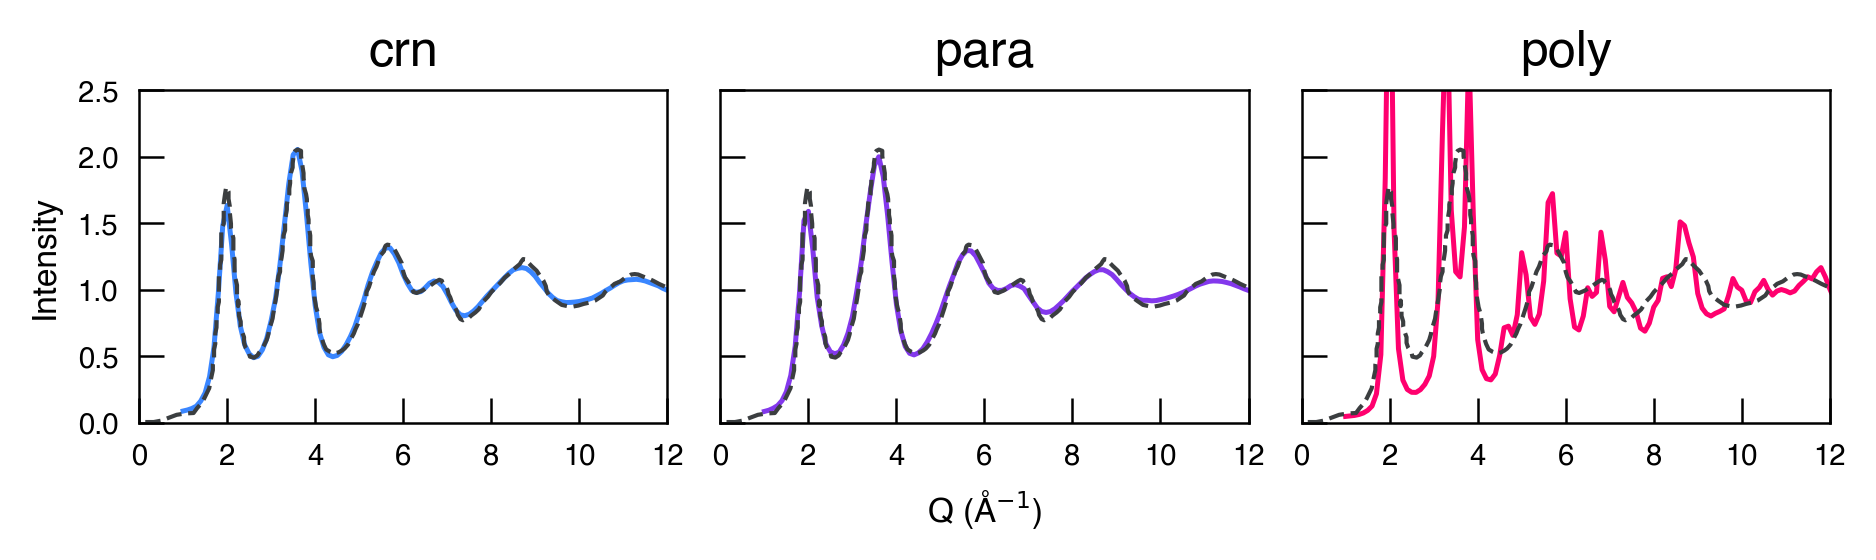

In [15]:
# Plotting Figure 5
colors=['#3A86FF','#8338EC', '#FF006E']

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16*cm,5*cm), sharex=True, sharey=True)#, gridspec_kw={'height_ratios': [5,1]})
axes=ax.ravel()

#Load experimental data
exp=np.loadtxt('../data/fig-5/Sq_Laaziri.csv', delimiter=",")

for stru, ax, col in zip(labels, axes, colors):
    comp=np.loadtxt(f'../data/fig-5/Sq-{stru}.csv', delimiter=",")
    S=comp[:,0]
    S=(S+0.5)*2
    ax.plot(comp[:,1], S, label=stru, linewidth=1.2, color=col)
    ax.plot(exp[:,0], exp[:,1] ,'--', color='#3B3E40')
    ax.set_ylim(bottom=0,top=2.5)
    ax.set_xlim(0,12)
    ax.set_title(stru)

axes[0].set_ylabel('Intensity')   
axes[1].set_xlabel('Q (Å$^{-1}$)')

fig.tight_layout()